In [1]:
import sys
sys.path.append('../src')

In [2]:
from data_loader import get_close
from returns import compute_returns, describe_returns, jarque_bera_test
from diagnostics import arch_lm_test, plot_acf_pacf, ljung_box_test, plot_qq
from models import fit_garch, fit_egarch, fit_gjr, compare_models
from plots import plot_returns, plot_conditional_volatility, plot_var_backtest

## 1. Introduction

In the financial sector, predicting market volatility is crucial for managing risk, making investment decisions and meeting regulatory requirements. Value-at-Risk (VaR) is the standard metric used by banks and funds to estimate the maximum potential loss a portfolio might face over a specific time frame. However, standard methods often fail because stock returns rarely follow the normal distribution and tend to experience extreme swings (fat tails). Additionally, volatility is not constant and naturally moves in waves. This project builds a rolling-window framework that uses volatility models to calculate daily VaR forecasts that adapt to changing market conditions.

 The project uses over 20 years of daily data from the S&P 500 index. I implement and compare three well-known volatility models: the classic GARCH (1,1), the Exponential GARCH (1,1), and the GJR-GARCH (1,1), all using a Student's t-distribution to better handle market crashes. To prove which model works best, I run them through statistical backtesting. This includes Kupiec’s (1995) test to check if the total number of losses is accurate, Christoffersen’s (1998) test to ensure that large losses do not cluster together back-to-back, and the official Basel III traffic light system used by financial regulators.


## 2. Data & Log Returns

In this section, we load the historical price dataset and transform it into daily log returns. Financial time series analysis requires log returns rather than raw prices to achieve stationarity and to compare asset performance accurately over time. We then analyze the basic statistical properties of our return data to test for normality.

Loading data from cache: ../data/sp500_prices.csv
===Descriptive Statistics===
count    5389.000000
mean        0.000337
std         0.012029
min        -0.127652
25%        -0.004058
50%         0.000738
75%         0.005711
max         0.109572
Name: Close, dtype: float64
Skewness: -0.4768
Kurtosis: 13.2313

===Jarque-Bera Normality Test===
Jarque-Bera Test: 39434.2149, p-value: 0.0000
Conclusion: returns are not normally distributed - GARCH modeling is justified.


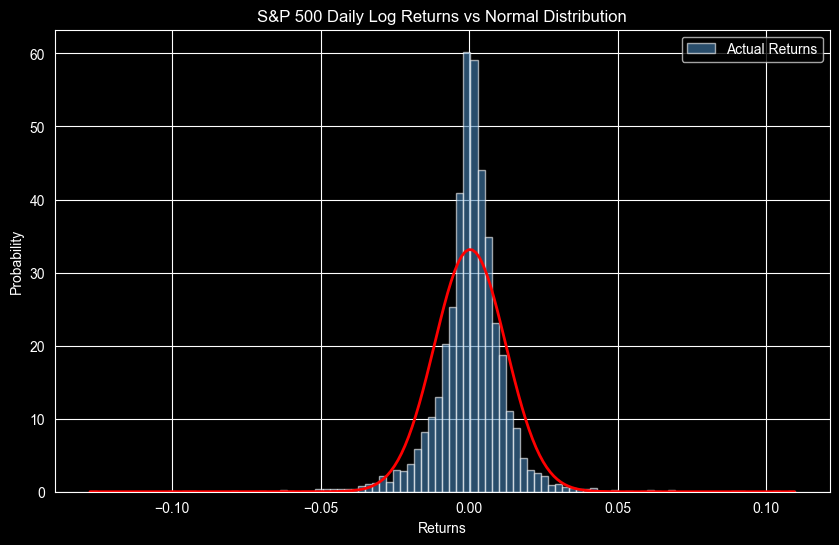

In [3]:
# historical close prices
close_prices = get_close()

# historical returns
returns = compute_returns(close_prices)

# descriptive statistics and Jarque-Bera test results
print("===Descriptive Statistics===")
describe_returns(returns)

print(f"\n===Jarque-Bera Normality Test===")
jarque_bera_test(returns)

plot_returns(returns)

## 3. Pre-fit Diagnostics

 Before fitting any GARCH specification, we must verify whether conditional heteroskedasticity - commonly known as "ARCH effects" - is actually present in our data. If the volatility of returns is constant over time, advanced dynamic models are unnecessary. We diagnose this by checking for time-dependence in the shocks (squared returns) using two primary tools: Autocorrelation Functions (ACF/PACF) and the formal Engle's ARCH LM (Lagrange Multiplier) test.

### Interpretation of Results

After running the diagnostics on our raw S&P 500 return data, we can draw the following conclusions:

* **Autocorrelation (ACF/PACF) Analysis:** While the ACF of raw log returns usually shows little to no significant correlation (confirming that market returns are mostly unpredictable), the ACF of **squared log returns** displays strong and persistent serial correlation that extends across dozens of lags. This is a classic indicator of *volatility clustering* - meaning that large shocks tend to be followed by large shocks, and quiet periods followed by quiet periods.
* **Engle's ARCH LM Test Conclusion:** The ARCH LM test evaluates the null hypothesis ($H_0$) that there are no ARCH effects in the residuals. The test yields an extremely high $F$-statistic and a $p$-value of 0.0000. Because the $p$-value is well below our 5% threshold, we strictly reject the null hypothesis.

**Conclusion:** The visual evidence from the ACF plots combined with the absolute rejection from the ARCH LM test provides definitive proof of time-varying volatility and strong ARCH effects in the S&P 500 returns. This confirms that the variance is not constant and fully justifies moving forward with the estimation of GARCH, EGARCH, and GJR-GARCH models.

===Engle's ARCH LM Test===
ARCH-LM Test (Raw Returns)
ARCH-LM Test Statistic: 1518.1962
ARCH-LM Test p-value: 0.0000
Conclusion: ARCH effects present - GARCH modeling is justified.

===Autocorrelation Plots===


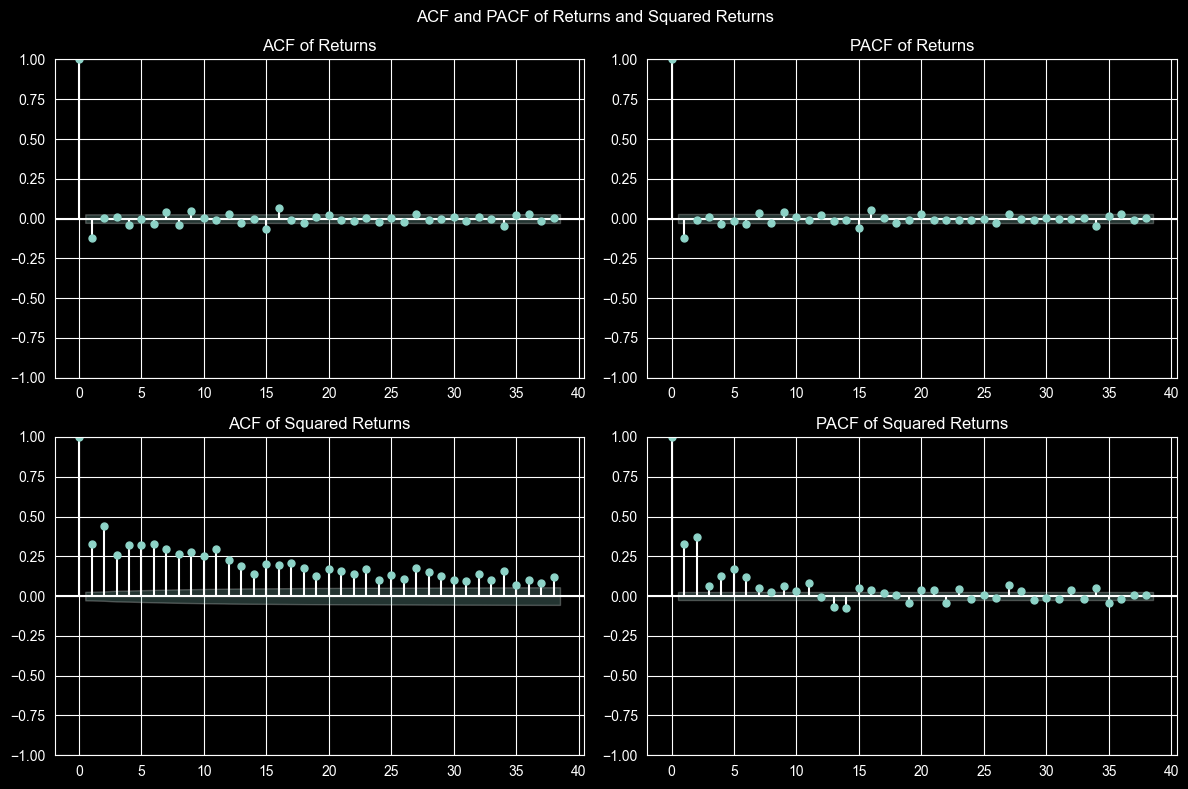

In [4]:
print(f"===Engle's ARCH LM Test===")
arch_lm_test(returns, label="Raw Returns")

print(f"\n===Autocorrelation Plots===")
plot_acf_pacf(returns)

## 4. Model Fitting & Estimation

In this section, we estimate the parameters for three different volatility models: Symmetric GARCH(1,1), Exponential GARCH(1,1) (EGARCH), and GJR-GARCH(1,1). To better handle market crashes and extreme days (high kurtosis), we fit all models using a Student's $t$-distribution.

### Note on Model Selection (Why GARCH(1,1)?)
Our ACF/PACF plots in Section 3 showed a significant spike at lag 2. While this technically suggests we could use a more complex model like GARCH(1,2), we choose to stay with the standard **(1,1) specification** for all models. In the industry, GARCH(1,1) is the gold standard because it is simple, stable, does not overfit the historical data, and easily captures long-term market trends.

### How to Interpret the Results

Once the models are fitted, we look at three key metrics in the output tables:

* **Volatility Persistence ($\alpha_1 + \beta_1$):** In the classic GARCH model, if this sum is very close to 1 (e.g., 0.98), it means volatility is highly persistent. After a big market shock, it will take a long time for the market to calm down and return to its average level.
* **The Leverage Effect (Asymmetry):** Markets usually drop much faster than they rise.
  * In the **EGARCH** model, a negative asymmetry parameter ($\gamma$) confirms that bad news spikes volatility more than good news.
  * In the **GJR-GARCH** model, a positive leverage parameter ($\gamma_1$) shows that during a crash, the model automatically adds extra weight to the risk calculation.
* **AIC & BIC (Finding the Winner):** We use Akaike (AIC) and Bayesian (BIC) Information Criteria to find the best model. The rule is simple: **the model with the lowest AIC and BIC scores wins**, as it provides the best accuracy without being overcomplicated.

In [5]:
garch_results = fit_garch(returns, "S&P 500")
egarch_results = fit_egarch(returns, "S&P 500")
gjr_results = fit_gjr(returns, "S&P 500")

model_results_list = [garch_results, egarch_results, gjr_results]

compare_models(model_results_list)

GARCH(1,1) Results (S&P 500)
omega              : 0.018315
alpha[1]           : 0.1360
beta[1]            : 0.8585
persistence        : 0.9944
nu (df)            : 5.4495
log-likelihood     : -7011.7692
AIC                : 14033.5383
BIC                : 14066.4989

EGARCH Results (S&P 500)
omega              : 0.013948
alpha[1]           : 0.2649
beta[1]            : 0.9803
persistence (beta) : 0.9803
nu (df)            : 5.3022
log-likelihood     : -7024.4809
AIC                : 14058.9617
BIC                : 14091.9223

GJR-GARCH(1,1) Results (S&P 500)
omega              : 0.021362
alpha[1]           : 0.0000
beta[1]            : 0.8660
gamma              : 0.2299
persistence        : 0.9810
nu (df)            : 5.9168
log-likelihood     : -6916.0834
AIC                : 13844.1669
BIC                : 13883.7195

         Model  Alpha   Beta  Gamma  Persistence     Nu  Log-Lik      AIC      BIC
    GARCH(1,1) 0.1360 0.8585    NaN       0.9944 5.4495 -7011.77 14033.54 14066.50
  

,Model,Alpha,Beta,Gamma,Persistence,Nu,Log-Lik,AIC,BIC
0,"GARCH(1,1)",0.1360,0.8585,NaN,0.9944,5.4495,-7011.77,14033.54,14066.50
1,EGARCH,0.2649,0.9803,NaN,0.9803,5.3022,-7024.48,14058.96,14091.92
2,"GJR-GARCH(1,1)",0.0000,0.8660,0.2299,0.9810,5.9168,-6916.08,13844.17,13883.72


### Interpretation of results:

Based on the model results, we can draw the following conclusions:

* High **Persistence** in all three models (ranging between 0.981 and 0.994) tells us that after a big shock, the normal levels of volatility will take a long time to mean-revert.
* According to **AIC** and **BIC** criteria, the GJR-GARCH(1,1) model is the clear winner, as the criteria values are the smallest, which indicates the best accuracy of the model.
* **Extreme Leverage Effect (Why Alpha is 0.0000):** Interestingly, the GJR-GARCH model estimates the $\alpha_1$ parameter (the impact of positive shocks) to be exactly **0.0000**, while the Gamma parameter (the leverage effect) is highly significant at **0.2299**. This provides empirical evidence of market psychology: positive returns (good news) have zero impact on next-day volatility, whereas negative returns (bad news) trigger immediate panic, increasing the next-day variance impact by the full value of Gamma (0.2299).

## 5. Post-Fit Diagnostics

The main goal of post-fit diagnostics is to verify whether our models successfully
captured the volatility dynamics. We apply two statistical tests and a visual
diagnostic to the standardized residuals $\hat{z}_t = \varepsilon_t / \hat{\sigma}_t$
from each fitted model.

**ARCH-LM Test:** Tests whether ARCH effects remain in the residuals after fitting.
A non-significant result ($p > 0.05$) confirms the variance equation did its job.

**Ljung-Box Test:** Tests whether the standardized residuals exhibit serial
autocorrelation at lags 1–10. A non-significant result would indicate the residuals
behave as white noise.

**Q-Q Plot:** Compares the empirical distribution of standardized residuals against
the fitted Student's $t$-distribution to assess whether the distributional assumption
is appropriate.

=== DIAGNOSTICS FOR GARCH ===
Ljung-Box Test (GARCH)
H0: no autocorrelation in residuals | tested at lags 1-10
---------------------------------------------
      lb_stat  lb_pvalue
1    8.531054   0.003491
2    8.918320   0.011572
3    9.797829   0.020365
4   10.663773   0.030614
5   14.895283   0.010819
6   17.163825   0.008700
7   17.955194   0.012174
8   19.112811   0.014268
9   19.456893   0.021576
10  21.679956   0.016821
---------------------------------------------
Conclusion: autocorrelation remains in residuals - model may be misspecified.
ARCH-LM Test (GARCH residuals)
ARCH-LM Test Statistic: 12.1769
ARCH-LM Test p-value: 0.2734
Conclusion: no ARCH effects in residuals - GARCH successfully captured volatility dynamics.


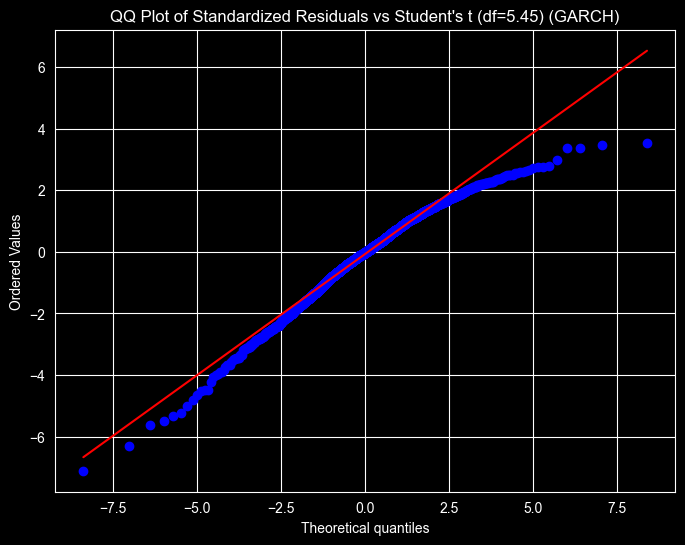

----------------------------------------
=== DIAGNOSTICS FOR EGARCH ===
Ljung-Box Test (EGARCH)
H0: no autocorrelation in residuals | tested at lags 1-10
---------------------------------------------
      lb_stat  lb_pvalue
1   10.268613   0.001353
2   10.579703   0.005043
3   11.397787   0.009758
4   12.344113   0.014968
5   16.295149   0.006050
6   18.434615   0.005233
7   19.236892   0.007477
8   20.450753   0.008759
9   20.761136   0.013754
10  22.939558   0.010972
---------------------------------------------
Conclusion: autocorrelation remains in residuals - model may be misspecified.
ARCH-LM Test (EGARCH residuals)
ARCH-LM Test Statistic: 17.7827
ARCH-LM Test p-value: 0.0587
Conclusion: no ARCH effects in residuals - GARCH successfully captured volatility dynamics.


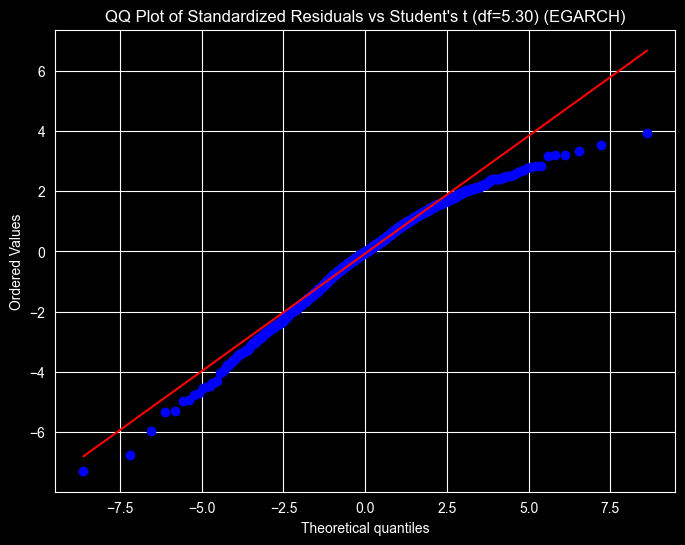

----------------------------------------
=== DIAGNOSTICS FOR GJR-GARCH ===
Ljung-Box Test (GJR-GARCH)
H0: no autocorrelation in residuals | tested at lags 1-10
---------------------------------------------
      lb_stat  lb_pvalue
1    9.057969   0.002616
2    9.788292   0.007490
3   10.696004   0.013489
4   11.565998   0.020888
5   15.309986   0.009117
6   17.717094   0.006979
7   18.369531   0.010409
8   19.506485   0.012373
9   19.624886   0.020374
10  21.683091   0.016803
---------------------------------------------
Conclusion: autocorrelation remains in residuals - model may be misspecified.
ARCH-LM Test (GJR-GARCH residuals)
ARCH-LM Test Statistic: 8.8576
ARCH-LM Test p-value: 0.5457
Conclusion: no ARCH effects in residuals - GARCH successfully captured volatility dynamics.


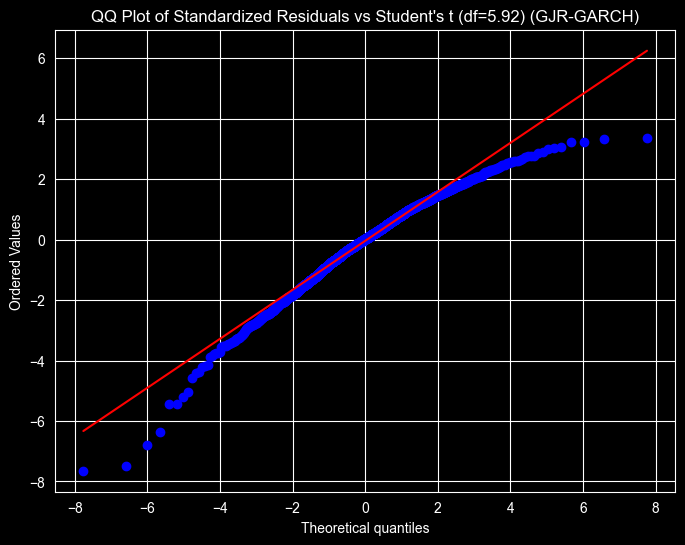

----------------------------------------


In [6]:
for name, model_res in zip(["GARCH", "EGARCH", "GJR-GARCH"], model_results_list):
    print(f"=== DIAGNOSTICS FOR {name} ===")

    results_obj = model_res['results_obj']
    std_resid = results_obj.std_resid
    estimated_df = results_obj.params['nu']

    ljung_box_test(std_resid, label=name)
    arch_lm_test(std_resid, label=f"{name} residuals", post_fit=True)
    plot_qq(std_resid, label=name, df=estimated_df)

    print("-" * 40)

### Interpretation

**ARCH-LM Test (post-fit):** All three models pass the ARCH-LM test on standardized
residuals - GARCH(1,1) (p = 0.273), EGARCH (p = 0.059), and GJR-GARCH(1,1) (p = 0.546).
This confirms that conditional heteroscedasticity has been successfully removed by all
three specifications. The variance equation did its job - volatility is no longer
clustering in the residuals.

**Ljung-Box Test:** All three models reject the null hypothesis of no autocorrelation
at lags 1–10 (p < 0.05 across all lags). This indicates remaining serial correlation
in the standardized residuals. Importantly, this is a **mean equation** issue, not a
variance equation issue - the GARCH framework only models conditional variance and does
not account for autocorrelation in returns themselves. An ARMA-GARCH specification
with an explicit AR mean equation would likely resolve this. This is noted as a
limitation and direction for future work.

**Key distinction:** The ARCH-LM and Ljung-Box tests capture different dynamics.
The ARCH-LM passing confirms the variance model is correctly specified. The Ljung-Box
failing reflects residual mean dynamics unrelated to volatility clustering - it does
not invalidate the GARCH models for the purpose of volatility forecasting and VaR
estimation.

#### Observations

The QQ plots of standardized residuals across all three models show good agreement
with the Student-t distribution in the central region, but reveal persistent
left-tail deviation - extreme negative residuals exceed what the fitted
t-distribution predicts. This suggests that even Student-t errors underestimate
crash risk during extreme market dislocations such as the 2008 financial crisis
and the COVID-19 crash of March 2020. This is a known limitation of parametric
volatility models and motivates the use of extreme value theory or historical
simulation as complementary approaches.